In [ ]:
import sys
import pandapower as pp
import pandapower.networks as nw
import pandas as pd
import nbformat
import matplotlib.pyplot as plt
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly


net = pp.networks.create_cigre_network_mv(with_der=False)


net.load['p_mw']= net.load['p_mw'] / 2
net.load['q_mvar']= net.load['q_mvar'] / 2

pp.runpp(net)
# print(net.load)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


         name  bus      p_mw    q_mvar  const_z_percent  const_i_percent  \
0     Load R1    1  7.497000  1.522331              0.0              0.0   
1     Load R3    3  0.138225  0.034642              0.0              0.0   
2     Load R4    4  0.215825  0.054091              0.0              0.0   
3     Load R5    5  0.363750  0.091164              0.0              0.0   
4     Load R6    6  0.274025  0.068677              0.0              0.0   
5     Load R8    8  0.293425  0.073539              0.0              0.0   
6    Load R10   10  0.237650  0.059561              0.0              0.0   
7    Load R11   11  0.164900  0.041328              0.0              0.0   
8    Load R12   12  7.497000  1.522331              0.0              0.0   
9    Load R14   14  0.104275  0.026134              0.0              0.0   
10   Load CI1    1  2.422500  0.796237              0.0              0.0   
11   Load CI3    3  0.112625  0.069799              0.0              0.0   
12   Load CI

# Step 4.4 (added price data on code from step 3.1)



All the additions in the code start with a comment "STEP 4.4."

Processing schedule_Airmee ...
  Tested 1 chargers -> success=False, unmet=439.297 kWh
Total price for schedule_Airmee is 96.08973698206468 euros.
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


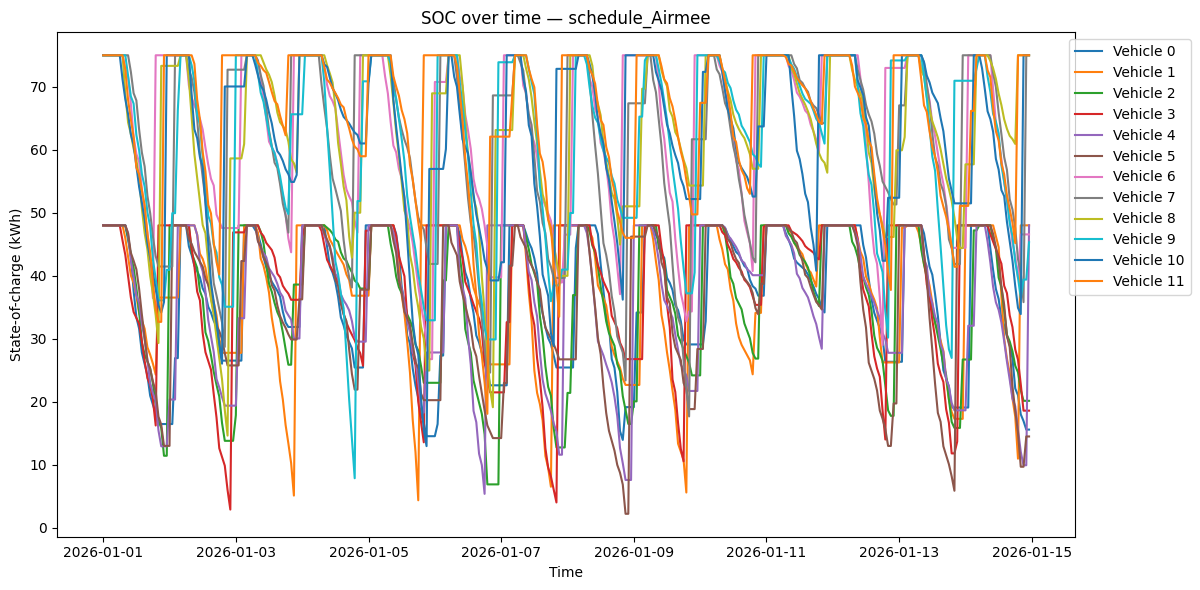

Processing schedule_Postnord ...
  Tested 1 chargers -> success=False, unmet=7540.873 kWh
  Tested 2 chargers -> success=False, unmet=3452.543 kWh
  Tested 3 chargers -> success=False, unmet=537.571 kWh
  Tested 4 chargers -> success=False, unmet=52.996 kWh
Total price for schedule_Postnord is 269.2522112726177 euros.
  Tested 5 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 5


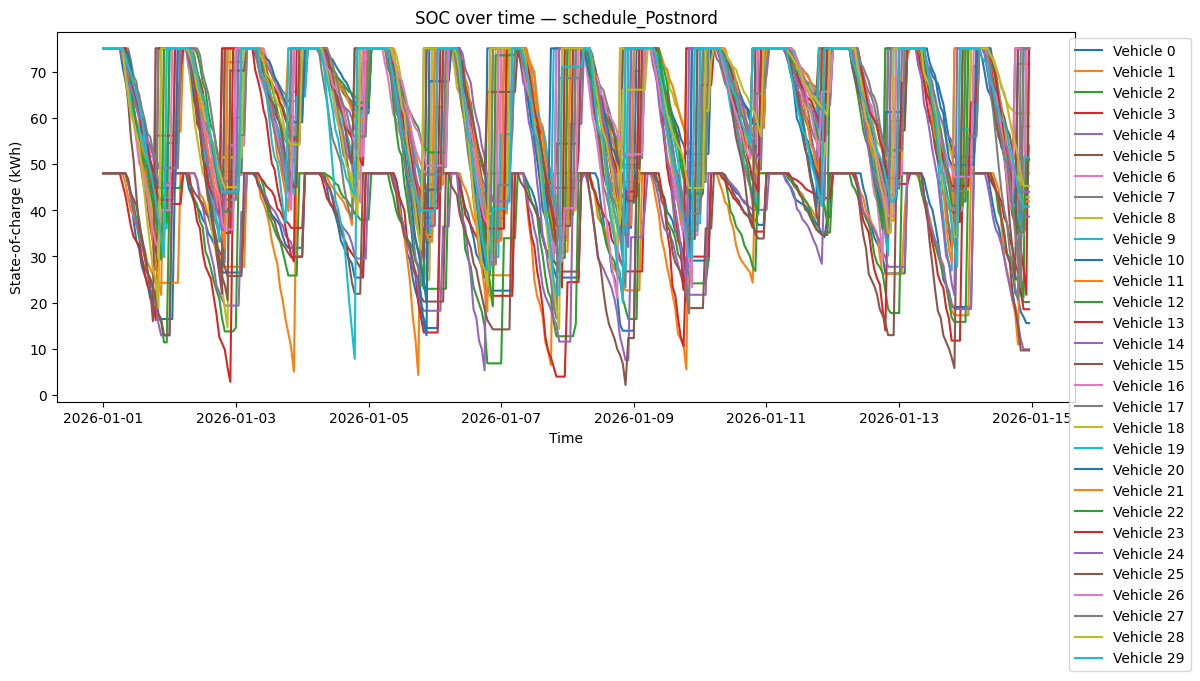

Processing schedule_Mathem ...
  Tested 1 chargers -> success=False, unmet=1250.650 kWh
Total price for schedule_Mathem is 144.40946564493427 euros.
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


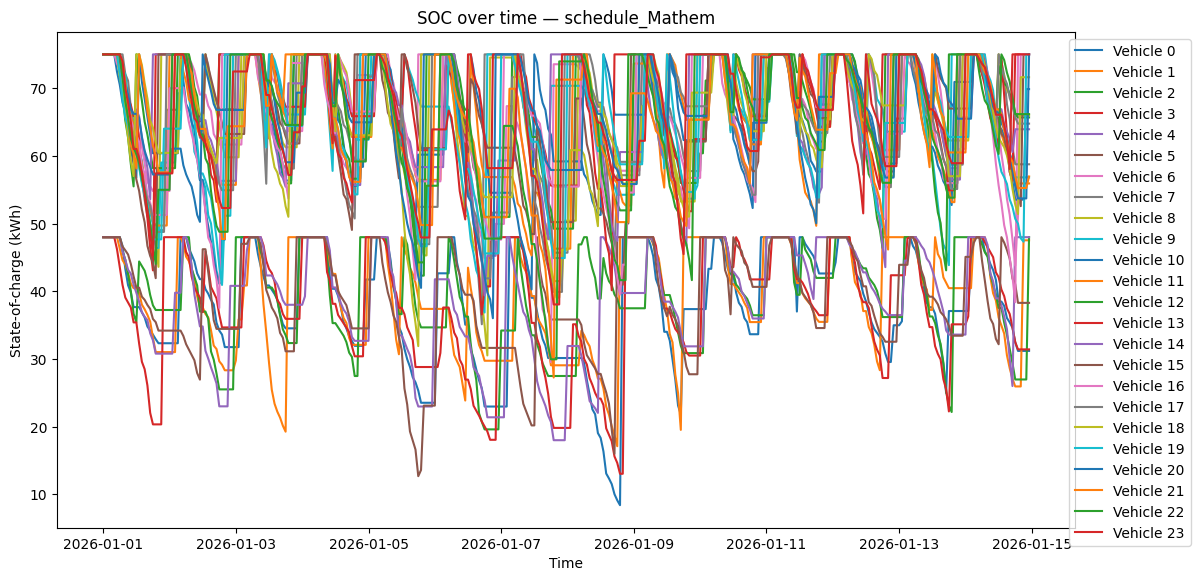

Processing schedule_ICA ...
  Tested 1 chargers -> success=False, unmet=5.377 kWh
Total price for schedule_ICA is 87.09182311088414 euros.
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


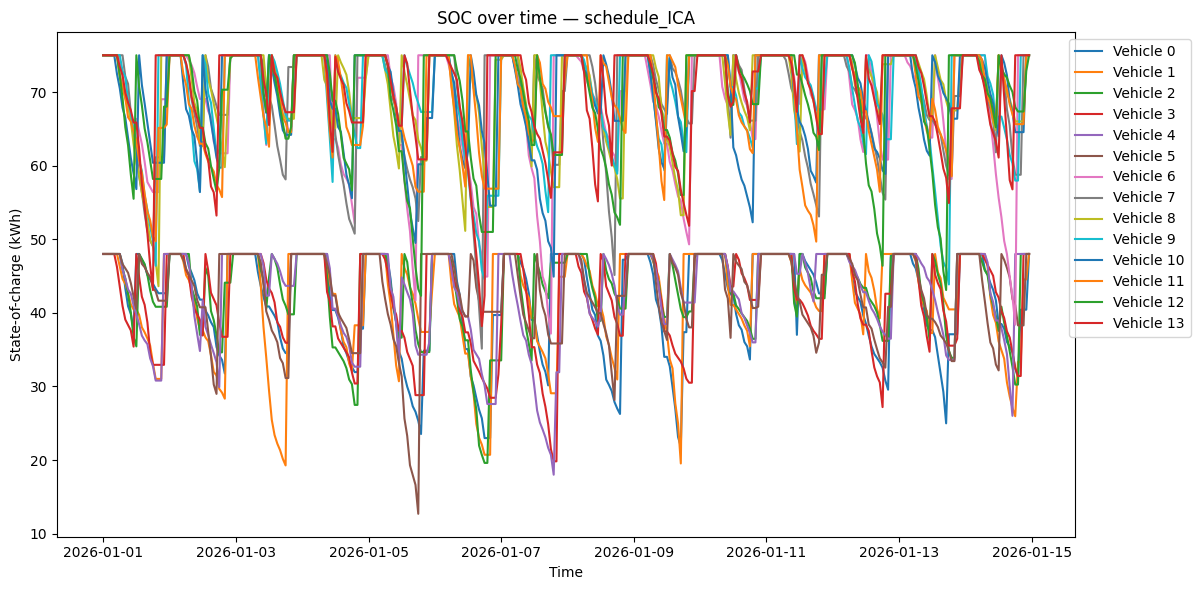

price for all shops: 596.8432370105007

Summary:
 schedule_Airmee: 2  (ok)
 schedule_Postnord: 5  (ok)
 schedule_Mathem: 2  (ok)
 schedule_ICA: 2  (ok)


In [4]:
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt
import csv

# -------------------------
# Config / assumptions
# -------------------------
notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

# Vehicle inlet rates (kW) and battery capacities (kWh)
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}

# Use Fast AC only: charger assumed capacity (kW). Change if your charger physical rating differs.
FAST_AC_CAPACITY_KW = 22.0

# Shops (folders contain shop.csv). Adjust names if necessary.
shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

# Maximum number of chargers to test (safety cap). Usually you won't need more chargers than vehicles.
MAX_CHARGERS_TO_TEST = 20


# *************************************************
# STEP 4.4. - opening price

def open_price_file():
    
    prices = {}
    date_format = '%d.%m.%Y %H:%M'

    with open("Prices.csv", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)              
        header = next(reader, None)        
        for row in reader:
            from_time = row[0].split(" - ")[0]
            prices[from_time] = float(row[1])
    prices_pd = pd.Series(prices)
    return prices_pd
# *************************************************


# -------------------------
# Helper: simulate week with m chargers for one shop
# -------------------------
def simulate_shop(file_path, m_chargers, prices, debug=False):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())

    # Vehicle type mapping
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

    # Precompute inlet per vehicle
    inlet = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW) for vid in vehicles}

    # --- FIX: dummy depot night before week starts ---
    # Start every vehicle with its full battery
    SOC = {}
    for vid in vehicles:
        vtype = vehicle_types.get(vid, None)
        cap = battery_capacities.get(vtype, 48.0)  # fallback = 48
        SOC[vid] = cap


    # *************************************************
    # STEP 4.4. - initializing price series
    time_index = sorted(df['date'].unique())
    T = len(time_index)
    idx_to_time = {idx+1: ts for idx, ts in enumerate(time_index)}

    ps = prices.copy()
    ps.index = pd.to_datetime(ps.index, format = '%d.%m.%Y %H:%M')
    price_by_idx = {}
    for idx in range(1, T+1):
        try:
            ts = idx_to_time[idx]
            price_by_idx[idx] = ps.iloc[idx-1]
        except:
            raise ValueError("error in creating price indexes")
        
    # *************************************************

    # Traces
    soc_trace = {vid: [] for vid in vehicles}
    time_trace = []

    unmet_energy_total = 0.0


    # Step 4.4. initiliazing variables
    # *************************************************
    total_price = 0.0

    index_counter = 0
    # *************************************************

    P_per_time = {}


    # --- main simulation loop ---
    for ts in timestamps:
        index_counter += 1
        df_h = df[df['date'] == ts]
        time_stamp_price = price_by_idx[index_counter]

        # Apply driving consumption
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            prev_soc = SOC.get(vid, 0.0)
            new_soc = prev_soc - cons
            if new_soc < -1e-9:
                unmet = -new_soc
                unmet_energy_total += unmet
                SOC[vid] = 0.0
            else:
                SOC[vid] = new_soc

        # Charging when at depot
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()
        available_energy = m_chargers * FAST_AC_CAPACITY_KW  # 1h window

        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid)
            cap = battery_capacities.get(vtype, 48.0)
            need = max(0.0, cap - SOC.get(vid, 0.0))
            max_accept = inlet.get(vid, FAST_AC_CAPACITY_KW)
            if need > 1e-9:
                needs.append({'vid': vid, 'need': need, 'max_accept': max_accept})

        take_per_ts = 0.0
        needs.sort(key=lambda x: x['need'], reverse=True)
        for n in needs:
            if available_energy <= 1e-9:
                break
            take = min(n['need'], n['max_accept'], available_energy)
            SOC[n['vid']] += take
            available_energy -= take
            take_per_ts += take

            # Step 4.4. summing cost
            # *************************************************
            total_price += take * time_stamp_price / 1000 # price per MWh
            # *************************************************

        for vid in vehicles:
            soc_trace[vid].append(SOC.get(vid, 0.0))
        time_trace.append(ts)
       
        P_per_time[ts] = take_per_ts

    success = (unmet_energy_total <= 1e-6)
    trace = {"time": time_trace, "soc_trace": soc_trace, "unmet_energy_total": unmet_energy_total, "charge_per_ts": P_per_time}
    if success:
        print("Total price for", shop, "is", total_price, "euros.")
    return success, trace, total_price



# -------------------------
# Find minimal chargers per shop using incremental search
# -------------------------
def find_min_chargers_for_shop(file_path, max_chargers=MAX_CHARGERS_TO_TEST, debug=False):
    prices = open_price_file()

    # Try m = 1..max_chargers
    for m in range(1, max_chargers + 1):
        success, trace, tot_price = simulate_shop(file_path, m, prices, debug=debug)
        print(f"  Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if debug:
            print(f"Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if success:
            return m, trace, tot_price
    # if we reach here, not feasible with tested chargers
    return None, None

# -------------------------
# Plotting: SOC time series per vehicle
# -------------------------
def plot_soc(trace, file_path, shop_name, save_fig=False):
    time = trace['time']
    soc = trace['soc_trace']

    plt.figure(figsize=(12, 6))
    for vid, series in soc.items():
        plt.plot(time, series, label=f"Vehicle {vid}")
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (kWh)")
    plt.title(f"SOC over time — {shop_name}")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        out = Path(file_path).with_suffix('.png')
        plt.savefig(out, dpi=150)
        print("Saved figure to", out)
    plt.show()

shop_charging_schedules = {}


# -------------------------
# Run for all shops
# -------------------------
if __name__ == "__main__":
    results = {}
    price_for_all = 0.0
    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"Processing {shop} ...")
        min_ch, trace, tot_price = find_min_chargers_for_shop(file, max_chargers=MAX_CHARGERS_TO_TEST, debug=False)
        shop_name = shop.replace("schedule_", "")
        shop_charging_schedules[shop_name] = trace['charge_per_ts']
        price_for_all += tot_price

        if min_ch is None:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}
        else:
            print(f"  -> Minimum chargers required: {min_ch}")
            results[shop] = {'min_chargers': min_ch, 'trace': trace}
            # plot SOC trace (you can set save_fig=True to write png)
            plot_soc(trace, file, shop, save_fig=False)

    print("price for all shops:", price_for_all)
    print("\nSummary:")
    for shop, info in results.items():
        print(f" {shop}: {info.get('min_chargers')}  ({info.get('reason','ok')})")


# Comparing the losses of dumb charging (this is related to step 5 only)

In [3]:
import sys
import pandapower as pp
import pandapower.networks as nw
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy



# ------------- 1. create network and apply initial change -------------
net0 = nw.create_cigre_network_mv(with_der=False)

net0.switch["closed"] = True  # close the tie switch

# scale down loads
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0

base_loads = net0.load['p_mw'].copy()

# ------------- 2. Read freight load profiles -------------
file_path_loads = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path_loads)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
).dt.tz_localize(None)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]




# Initialize shop placements
shop_to_bus = {
    "ICA": 13,
    "Mathem": 6,
    "Postnord": 10,
    "Airmee": 6,
}


# Function to create network with shop loads
def create_network_with_shops(net_base, shop_mapping, timestamp, charging_loads):
    """Create a network with base loads + shop loads at specified buses"""
    net = copy.deepcopy(net_base)
    
    # Reset to base loads first
    net.load['p_mw'] = base_loads.copy()
    
    # Add shop loads to their respective buses
    for shop, bus in shop_mapping.items():
       
        charging_load_shop = charging_loads[shop]
        if bus is not None:
            # Find if there's already a load at this bus
            existing_loads = net.load[net.load.bus == bus]
            
            if not existing_loads.empty:
                # Add to existing load
                load_idx = existing_loads.index[0]
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_freight
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                net.load.at[load_idx, 'p_mw'] += add_mw_charging
            else:
                # Create new load at this bus
                add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                add_mw_charging = charging_load_shop[timestamp] / 1000.0
                add_mw = add_mw_charging + add_mw_freight
                pp.create_load(net, bus=bus, p_mw=add_mw, q_mvar=0)
    
    return net


      


# ------------- 6. Run final simulation with all shops -------------
print("Running final simulation with all shops...")

line_indices = list(net0.line.index)
col_names = [f"line_{i}" for i in line_indices]
res_lines_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)

trafo_indices = list(net0.trafo.index)
col_names = [f"trafo_{i}" for i in trafo_indices]
res_trafo_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)


all_losses = 0.0

for ts_idx, ts in enumerate(load_profile.index):
    if ts_idx % 24 == 0:  # Print progress every 24 hours
        print(f"Final simulation progress: {ts}")
    
    net_final = create_network_with_shops(net0, shop_to_bus, ts, shop_charging_schedules)

    try:
        pp.runpp(net_final, calculate_voltage_angles=False)
        line_loading = net_final.res_line.loading_percent 
        line_losses = net_final.res_line.pl_mw
        trafo_loading = net_final.res_trafo.loading_percent
        bus_voltage = net_final.res_bus.vm_pu
        for li in line_indices:
            res_lines_final_losses.at[ts, f"line_{li}"] = line_losses.at[li]
            all_losses += line_losses.at[li]

        trafo_losses = net_final.res_trafo.pl_mw
        for tr in trafo_indices:
            res_trafo_final_losses.at[ts, f"trafo_{tr}"] = trafo_losses.at[tr]
            all_losses += trafo_losses.at[tr]



    except Exception as e:
        print(f"Final power flow failed at {ts}: {e}")
        


print(all_losses)

'''

P_per_time = {}
for t in model.TIME:
    all_P = 0.0
    for v in model.VEH:
        all_P += float(value(model.P[v, t]))
    P_per_time[idx_to_time[t]] = all_P


'''

Running final simulation with all shops...
Final simulation progress: 2026-01-01 00:00:00
Final simulation progress: 2026-01-02 00:00:00
Final simulation progress: 2026-01-03 00:00:00
Final simulation progress: 2026-01-04 00:00:00
Final simulation progress: 2026-01-05 00:00:00
Final simulation progress: 2026-01-06 00:00:00
Final simulation progress: 2026-01-07 00:00:00
Final simulation progress: 2026-01-08 00:00:00
Final simulation progress: 2026-01-09 00:00:00
Final simulation progress: 2026-01-10 00:00:00
Final simulation progress: 2026-01-11 00:00:00
Final simulation progress: 2026-01-12 00:00:00
Final simulation progress: 2026-01-13 00:00:00
Final simulation progress: 2026-01-14 00:00:00
65.40833004239417


'\n\nP_per_time = {}\nfor t in model.TIME:\n    all_P = 0.0\n    for v in model.VEH:\n        all_P += float(value(model.P[v, t]))\n    P_per_time[idx_to_time[t]] = all_P\n\n\n'